# Test Sampling in Patch Dataset

This notebook instantiates the `GWPatchDatasetMultiCol` to let you visually inspect the spatial downsampling process (both `static` and `dynamic` strategies) without loading any model-related code.

In [1]:
import os
import sys
import matplotlib.pyplot as plt

# Add the repository root to the python path
sys.path.append(os.path.abspath('/scratch/yl75/ak4177/src/GW_SciML/'))

from src.data.patch_dataset_multi_col import GWPatchDatasetMultiCol

In [2]:
# BASE_DATA_DIR = "/Users/arpitkapoor/Projects/groundwater/data/feflow_data"
BASE_DATA_DIR = "/scratch/yl75/ak4177/data/feflow_data"

PATCH_DATA_DIR = os.path.join(BASE_DATA_DIR, "patch_all_ts")

import torch

# Defining standard targets (e.g. mass concentration, head)
target_col_indices = [0, 1]

# Provide a simple transform to convert numpy arrays to PyTorch tensors 
# this mimics what calculate_obs_transform() does in gino_train.py
def simple_obs_transform(obs_data):
    return torch.tensor(obs_data, dtype=torch.float32)

common_kwargs = dict(
    data_path=PATCH_DATA_DIR,
    dataset='train',
    val_ratio=0.3,
    input_window_size=5,
    output_window_size=1,
    target_col_indices=target_col_indices,
    obs_transform=simple_obs_transform,
    forcings_required=True,
    forcings_transform=simple_obs_transform,
)

## Instantiate Datasets

Here we verify the patch nodes by creating three separate dataset states:
1. **Original Dataset**: Keeps 100% of the nodes (`resolution_ratio=1.0`).
2. **Static Sampled Dataset**: Subsamples every patch uniformly (`resolution_ratio=0.5`).
3. **Dynamic Sampled Dataset**: Keeps a varying amount of nodes per patch depending on their temporal variance, targeting `0.5` overall with a minimum bounded to `0.1`.

In [3]:
print("Loading Original Dataset (no sampling)...")
ds_original = GWPatchDatasetMultiCol(
    **common_kwargs,
    resolution_ratio=1.0,
    sampling_strategy='static',
)

resolution_ratio_1 = 0.4

print(f"\nLoading Static Sampled Dataset ({resolution_ratio_1*100:.1f}% nodes)...")
ds_static_1 = GWPatchDatasetMultiCol(
    **common_kwargs,
    resolution_ratio=resolution_ratio_1,
    sampling_strategy='static',
)

resolution_ratio_2 = 0.3

print(f"\nLoading Static Sampled Dataset ({resolution_ratio_2*100:.1f}% nodes)...")
ds_static_2 = GWPatchDatasetMultiCol(
    **common_kwargs,
    resolution_ratio=resolution_ratio_2,
    sampling_strategy='static',
)

Loading Original Dataset (no sampling)...
Static sampling enabled. Uniform patch ratio: 1.0000
Patch 1: no subsampling (ratio=1.0000). Core nodes=3409, Ghost nodes=170
Patch 2: no subsampling (ratio=1.0000). Core nodes=3332, Ghost nodes=332
Patch 3: no subsampling (ratio=1.0000). Core nodes=4312, Ghost nodes=215
Patch 4: no subsampling (ratio=1.0000). Core nodes=2905, Ghost nodes=435
Patch 5: no subsampling (ratio=1.0000). Core nodes=2562, Ghost nodes=128
Patch 6: no subsampling (ratio=1.0000). Core nodes=2898, Ghost nodes=432
Patch 7: no subsampling (ratio=1.0000). Core nodes=4319, Ghost nodes=645
Patch 8: no subsampling (ratio=1.0000). Core nodes=3409, Ghost nodes=340
Patch 9: no subsampling (ratio=1.0000). Core nodes=2569, Ghost nodes=384
Patch 10: no subsampling (ratio=1.0000). Core nodes=3325, Ghost nodes=332
Patch 11: no subsampling (ratio=1.0000). Core nodes=2922, Ghost nodes=292
Patch 12: no subsampling (ratio=1.0000). Core nodes=2202, Ghost nodes=330
Patch 13: no subsampling (

## Compare and Visualize Spatial Distribution

We'll visualize the 3D space (`X`, `Y`, `Z`) of the nodes to inspect the outcome of the subsampling.

In [4]:
import numpy as np

def build_patch_coords(coords_list, coord_key="core_coords"):
    patch_coords = {}
    weights = {}
    for item in coords_list:
        if isinstance(item, dict) and "patch_id" in item:
            pid = item["patch_id"]
            if pid not in patch_coords:
                c = item.get(coord_key)
                if c is not None:
                    patch_coords[pid] = np.asarray(c)
                    weights[pid] = item.get("weights")
            else:
                assert(np.isclose(patch_coords[pid], item.get(coord_key), atol=1e-6).all())
    return patch_coords, weights

In [5]:
coords_orig_map, weights_orig_map = build_patch_coords(ds_original.coords)
coords_stat_1_map, weights_stat_1_map = build_patch_coords(ds_static_1.coords)
coords_stat_2_map, weights_stat_2_map = build_patch_coords(ds_static_2.coords)
# coords_dyn_map, weights_dyn_map = build_patch_coords(ds_dynamic.coords)

In [6]:
# for pid in coords_orig_map.keys():
#     print(f"Patch ID: {pid} -- Dynamic Sampled Coords Ratio: {coords_dyn_map[pid].shape[0]/ coords_orig_map[pid].shape[0]:.2f}")

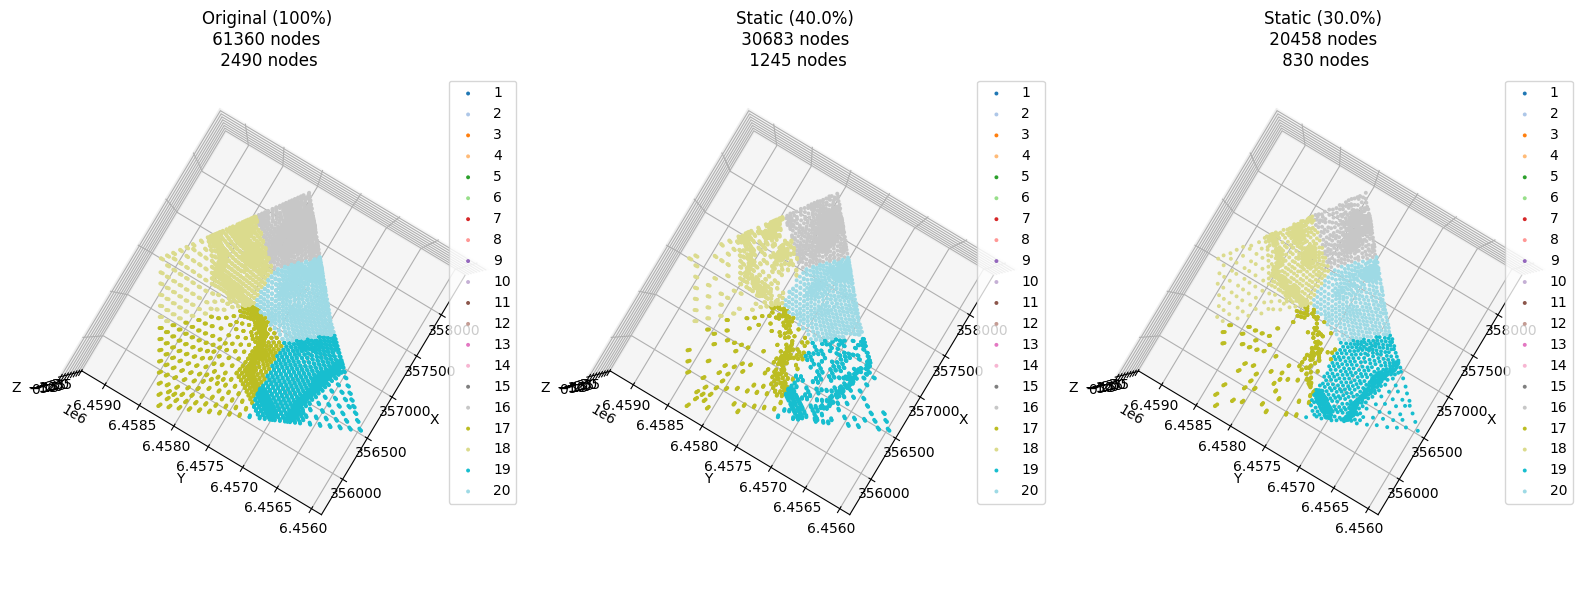

In [10]:
# 1. Define the colors array using the tab20 colormap (20 distinct colors)
# Adding a placeholder at index 0 so we can use 1-based indexing (1 to 20)
colors = [None] + list(plt.cm.tab20.colors)

fig, axes = plt.subplots(1, 3, figsize=(16, 7), subplot_kw=dict(projection='3d'))

# running limits across patches
running_min = np.array([np.inf, np.inf, np.inf])
running_max = np.array([-np.inf, -np.inf, -np.inf])

orig_node_count = sum(coords.shape[0] for coords in coords_orig_map.values())
stat_1_node_count = sum(coords.shape[0] for coords in coords_stat_1_map.values())
stat_2_node_count = sum(coords.shape[0] for coords in coords_stat_2_map.values())
# dyn_node_count = sum(coords.shape[0] for coords in coords_dyn_map.values())

titles = [f'Original (100%)\n {orig_node_count} nodes', f'Static ({resolution_ratio_1*100:.1f}%)\n {stat_1_node_count} nodes', f'Static ({resolution_ratio_2*100:.1f}%)\n {stat_2_node_count} nodes']#, f'Dynamic (60%)\n {dyn_node_count} nodes']

# Compute global weight range for a consistent colorbar across all subplots
all_weights = [w for wmap in [weights_orig_map, weights_stat_1_map, weights_stat_2_map] 
               for w in wmap.values() if w is not None]
vmin = min(w.min() for w in all_weights)
vmax = max(w.max() for w in all_weights)

# Keep track of the last scatter handle per axis for the colorbar
last_scat = [None, None, None]

selected_patch_id = 1

for patch_id in range(selected_patch_id, 21):

    coords_orig = coords_orig_map[patch_id]
    coords_stat_1 = coords_stat_1_map[patch_id]
    coords_stat_2 = coords_stat_2_map[patch_id]
    # coords_dyn = coords_dyn_map[patch_id]

    # weights
    weights_orig = weights_orig_map[patch_id]
    weights_stat_1 = weights_stat_1_map[patch_id]
    weights_stat_2 = weights_stat_2_map[patch_id]
    # weights_dyn = weights_dyn_map[patch_id]

    # update running limits using original coords
    orig_min = coords_orig.min(axis=0)
    orig_max = coords_orig.max(axis=0)
    running_min = np.minimum(running_min, orig_min)
    running_max = np.maximum(running_max, orig_max)

    pad = (running_max - running_min) * 0.05
    pad[pad == 0] = 1.0  # fallback if any dimension has zero span

    x_lim = (running_min[0] - pad[0], running_max[0] + pad[0])
    y_lim = (running_min[1] - pad[1], running_max[1] + pad[1])
    z_lim = (running_min[2] - pad[2], running_max[2] + pad[2])

    data_sets = [coords_orig, coords_stat_1, coords_stat_2]#, coords_dyn]
    weights_sets = [weights_orig, weights_stat_1, weights_stat_2]#, weights_dyn]

    for i, (coords, weights, title) in enumerate(zip(data_sets, weights_sets, titles)):
        ax = axes[i]
        # apply the running limits right before plotting
        ax.set_xlim(*x_lim)
        ax.set_ylim(*y_lim)
        # ax.set_zlim(*z_lim)

        # Changed `c` to `color` to assign the unique patch color. 
        # Note: vmin and vmax won't affect the plot here because we are forcing an explicit color.
        selected_nodes = (coords[:,-1]<-25) & (coords[:,-1]>-36)
        if len(selected_nodes>=1):
            scat = ax.scatter(coords[selected_nodes, 0], coords[selected_nodes, 1], coords[selected_nodes, 2], 
                              s=8, alpha=1.0, edgecolors='none', 
                              color=colors[int(patch_id)], label=f'{patch_id}') #, vmin=vmin, vmax=vmax)
            last_scat[i] = scat
            ax.set_title(f"{title} \n {len(coords)} nodes")
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')
            ax.legend()

# Add a colorbar to each subplot after the loop
# Note: Because the scatter points are now colored by patch_id rather than 'weights', 
# this colorbar will map to the final patch's color/ID, not the actual sampling weights.
for i, ax in enumerate(axes):
#     if last_scat[i] is not None:
#         fig.colorbar(last_scat[i], ax=ax, shrink=0.5, pad=0.1, label='Sampling Weight')

    # Aspect Ratio
    ax.set_box_aspect((1, 1, 1.1))

    # View Angle
    ax.view_init(elev=90, azim=215)

    # Padding
    ax.xaxis.labelpad = 15
    ax.yaxis.labelpad = 10
    ax.zaxis.labelpad = 5

plt.tight_layout()
plt.show()

In [8]:
# del coords_orig_map, weights_orig_map
# del coords_stat_map, weights_stat_map
# # del coords_dyn_map, weights_dyn_map

# # del ds_original
# del ds_static
# # del ds_dynamic

ds = ds_original

Randomly sampled indices from original dataset: [24037 23477  8310]
Sample 0 - Coords shape: (2856, 3), Inputs shape: torch.Size([2856, 2]), Outputs shape: torch.Size([2856, 2])
Sample 1 - Coords shape: (3696, 3), Inputs shape: torch.Size([3696, 2]), Outputs shape: torch.Size([3696, 2])
Sample 2 - Coords shape: (4319, 3), Inputs shape: torch.Size([4319, 2]), Outputs shape: torch.Size([4319, 2])


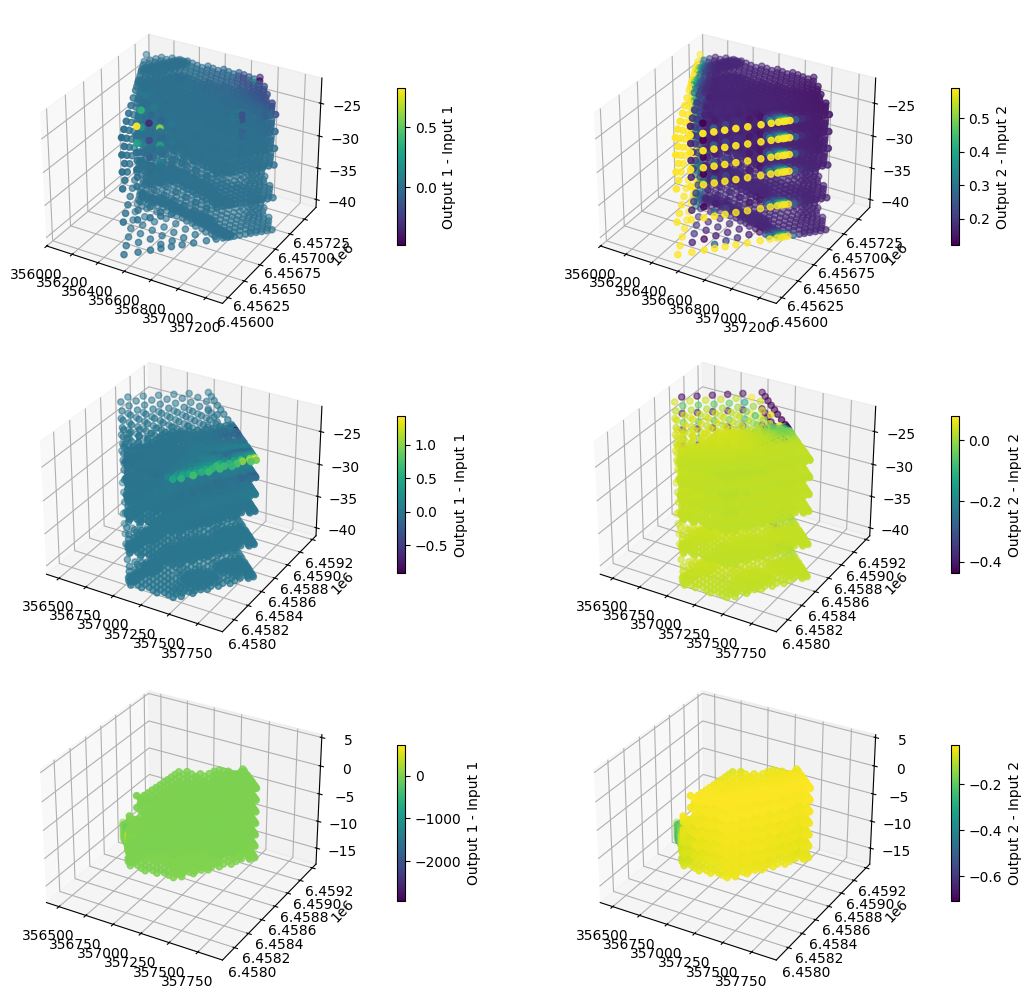

In [9]:
index = np.random.choice(len(ds), size=3, replace=False)
print("Randomly sampled indices from original dataset:", index)

# Plot input-output pairs for the sampled indices
fig, axes = plt.subplots(3, 2, figsize=(12, 10), subplot_kw=dict(projection='3d'))

for i, idx in enumerate(index):
    coords = ds[idx]['core_coords']
    inputs = ds[idx]['core_in'][:, :ds.input_window_size*len(ds.target_col_indices)].reshape(-1, ds.input_window_size, len(ds.target_col_indices))[:, 0, :]
    outputs = ds[idx]['core_out'].reshape(-1, ds.output_window_size, len(ds.target_col_indices))[:, 0, :]
    print(f"Sample {i} - Coords shape: {coords.shape}, Inputs shape: {inputs.shape}, Outputs shape: {outputs.shape}")

    diff1 = axes[i, 0].scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=outputs[:, 0] - inputs[:, 0], label='Output 1 - Input 1')
    diff2 = axes[i, 1].scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=outputs[:, 1] - inputs[:, 1], label='Output 2 - Input 2')
    # axes[i, 2].scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=outputs[:, 0], label='Output 1')
    # axes[i, 3].scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=outputs[:, 1], label='Output 2')

    fig.colorbar(diff1, ax=axes[i, 0], shrink=0.5, pad=0.1, label='Output 1 - Input 1')
    fig.colorbar(diff2, ax=axes[i, 1], shrink=0.5, pad=0.1, label='Output 2 - Input 2')

plt.tight_layout()
plt.show()


Randomly sampled indices from original dataset: [22497]
Sample 2 - Coords shape: (2196, 3), Inputs shape: torch.Size([2196, 5, 2]), Outputs shape: torch.Size([2196, 2])


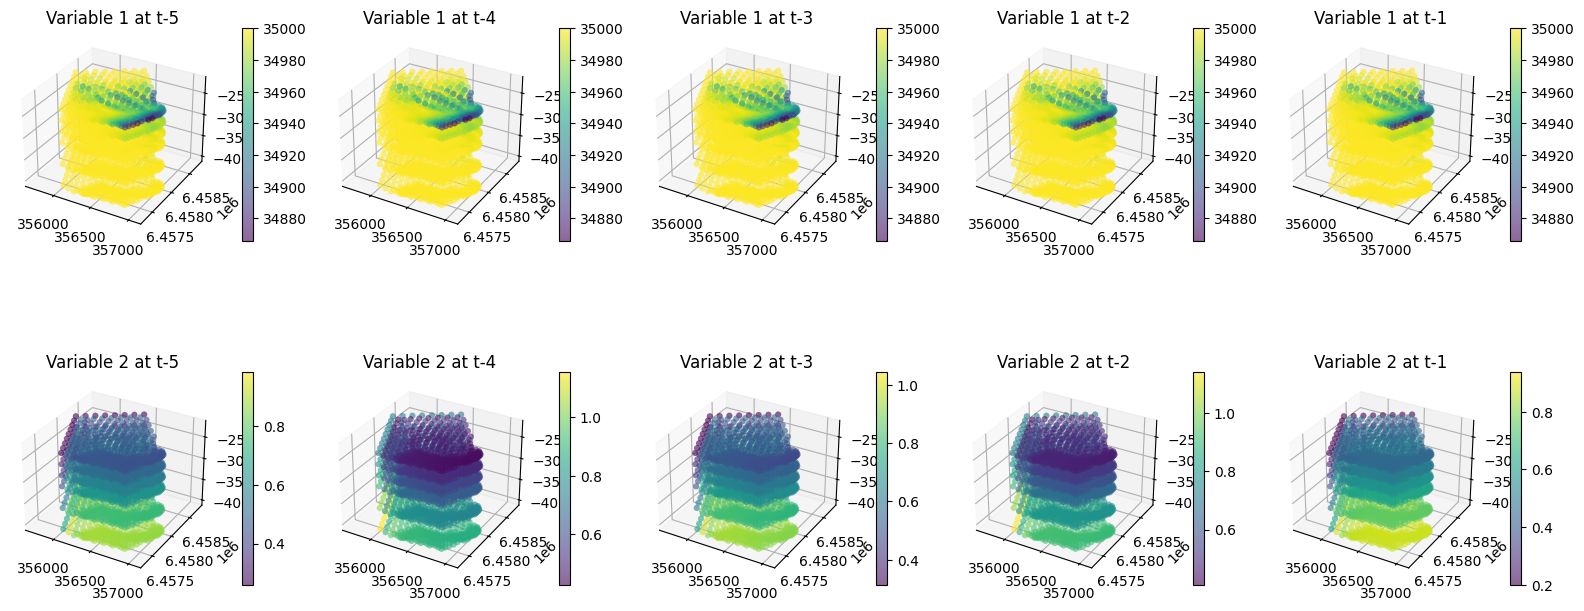

In [10]:
index = np.random.choice(len(ds), size=1, replace=False)
print("Randomly sampled indices from original dataset:", index)

coords = ds[index[0]]['core_coords']
inputs = ds[index[0]]['core_in'][:, :ds.input_window_size*len(ds.target_col_indices)].reshape(-1, ds.input_window_size, len(ds.target_col_indices))
outputs = ds[index[0]]['core_out']#.reshape(-1, ds.output_window_size, len(ds.target_col_indices))[:, 0, :]
print(f"Sample {i} - Coords shape: {coords.shape}, Inputs shape: {inputs.shape}, Outputs shape: {outputs.shape}")


# n_channels = ds[index[0]]['core_in'].shape[-1]

fig, axes = plt.subplots(inputs.shape[-1], inputs.shape[1], figsize=(16, 8), subplot_kw=dict(projection='3d'))

for i in range(inputs.shape[-1]):

    for j in range(inputs.shape[1]):

        ax = axes[i, j]
        scat = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=inputs[:, j, i], alpha=0.6, edgecolors='none')
        fig.colorbar(scat, ax=ax, shrink=0.5, pad=0.1)
        ax.set_title(f'Variable {i+1} at t-{inputs.shape[1]-j}')

plt.tight_layout()
plt.show()
